# Preparazione del dataset per la Siamese Network

In questo notebook viene costruita la pipeline dati necessaria per
l'addestramento della Siamese Network.

Il notebook utilizza il manifest prodotto nella fase di esplorazione
del dataset e la rappresentazione FCGR studiata nel notebook precedente.

La configurazione iniziale utilizza `k=6`, scelto come compromesso tra
risoluzione, sparsità e costo computazionale.

Gli obiettivi di questa fase sono:

1. caricare il manifest dell'esperimento;
2. mantenere separati train, validation e test;
3. recuperare le sequenze dal FASTA;
4. generare FCGR normalizzate;
5. costruire coppie positive e negative dinamicamente;
6. bilanciare positive e negative pairs;
7. evitare di materializzare tutte le combinazioni possibili;
8. costruire i `DataLoader` PyTorch;
9. verificare forma e correttezza dei batch.

La convenzione utilizzata per le coppie è:

- `target = 1`: coppia positiva, stessa classe;
- `target = 0`: coppia negativa, classi differenti.

In [1]:
from pathlib import Path
from functools import lru_cache
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)

In [2]:
PROJECT_ROOT = Path("..")

RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_primary_manifest.tsv"
)


FASTA_PATH = (
    RAW_DIR
    / "eccdna_disease_detection.body.fa"
)


print(
    "Manifest:",
    MANIFEST_PATH.exists(),
    MANIFEST_PATH
)

print(
    "FASTA:",
    FASTA_PATH.exists(),
    FASTA_PATH
)

Manifest: True ..\data\processed\siamese_primary_manifest.tsv
FASTA: True ..\data\raw\eccdna_disease_detection.body.fa


In [3]:
# ============================================================
# RIPRODUCIBILITÀ
# ============================================================

RANDOM_STATE = 42


# ============================================================
# FCGR
# ============================================================

# k principale scelto nel notebook 02
DEFAULT_K = 7 # k = 5, 6,...,10


# ============================================================
# PAIR SAMPLING
# ============================================================

POSITIVE_PAIR_PROBABILITY = 0.50


# Numero di coppie che il Dataset espone per ogni epoca.
#
# NON corrisponde al numero di sample originali.
# Le coppie vengono generate dinamicamente.

TRAIN_PAIRS_PER_EPOCH = 50_000

VAL_PAIRS = 10_000

TEST_PAIRS = 10_000


# ============================================================
# VALIDATION / TEST POOL
# ============================================================

# Train utilizzerà tutti i sample già downsamplati
# nel notebook 01.
#
# Per la valutazione pair-based utilizziamo al massimo
# 1000 sample per classe da validation e test.
#
# Gli split originali NON vengono modificati.

MAX_EVAL_SAMPLES_PER_CLASS = 1_000


# ============================================================
# FCGR CACHE
# ============================================================

# Una FCGR k=6 float32 occupa:
# 64 * 64 * 4 byte ≈ 16 KB.
#
# 4096 FCGR ≈ 64 MB, escluso overhead.

FCGR_CACHE_SIZE = 4096


# ============================================================
# DATALOADER
# ============================================================

BATCH_SIZE = 64

# Inizialmente usiamo 0 perché siamo in Jupyter/Windows
# e utilizziamo anche una cache in memoria.
NUM_WORKERS = 0

In [4]:
random.seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)

torch.manual_seed(
    RANDOM_STATE
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        RANDOM_STATE
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "PyTorch:",
    torch.__version__
)

print(
    "Device:",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

PyTorch: 2.12.0+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


# Caricamento del manifest

Il manifest contiene i sample selezionati nel notebook 01.

Il training set è già stato sottoposto a downsampling, mentre validation
e test mantengono la loro distribuzione originale.

Prima di costruire qualsiasi coppia vengono mantenuti separati i tre split.

In [5]:
metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    low_memory=False
)


# Gli ID vengono trattati sempre come stringhe.

metadata["id"] = (
    metadata["id"]
    .astype(str)
)


print(
    "Shape:",
    metadata.shape
)

print(
    "Classi:",
    metadata[
        "disease_clean"
    ].nunique()
)

print(
    "ID unici:",
    metadata[
        "id"
    ].nunique()
)

print(
    "Duplicati:",
    metadata[
        "id"
    ].duplicated().sum()
)

Shape: (665681, 12)
Classi: 18
ID unici: 665681
Duplicati: 0


In [6]:
class_distribution = pd.crosstab(
    metadata["disease_clean"],
    metadata["split_cluster"]
)


class_distribution = (
    class_distribution
    .sort_values(
        "train",
        ascending=False
    )
)


class_distribution

split_cluster,test,train,val
disease_clean,,,
colorectal cancer,4422,10000,8511
cervical adenocarcinoma,1958,10000,3719
ovarian cancer,8355,10000,16767
prostate cancer,8263,10000,16224
healthy,20852,10000,43143
gastric cancer,128668,10000,252571
hiv infectious disease,2157,10000,4158
lymphoma,3409,10000,6776
leukemia,1138,10000,2318


In [7]:
class_mapping = (
    metadata[
        [
            "disease_clean",
            "class_id"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "class_id"
    )
    .reset_index(
        drop=True
    )
)


CLASS_TO_ID = dict(
    zip(
        class_mapping[
            "disease_clean"
        ],
        class_mapping[
            "class_id"
        ]
    )
)


ID_TO_CLASS = {
    class_id: disease
    for disease, class_id
    in CLASS_TO_ID.items()
}


display(
    class_mapping
)

,disease_clean,class_id
0,gastric cancer,0
1,healthy,1
2,ovarian cancer,2
3,prostate cancer,3
4,colorectal cancer,4
5,lymphoma,5
6,hiv infectious disease,6
7,cervical adenocarcinoma,7
8,leukemia,8
9,primary pulmonary hypertension,9


In [8]:
train_metadata = metadata[
    metadata[
        "split_cluster"
    ] == "train"
].copy()


val_metadata = metadata[
    metadata[
        "split_cluster"
    ] == "val"
].copy()


test_metadata = metadata[
    metadata[
        "split_cluster"
    ] == "test"
].copy()


print(
    "Train:",
    f"{len(train_metadata):,}"
)

print(
    "Validation:",
    f"{len(val_metadata):,}"
)

print(
    "Test:",
    f"{len(test_metadata):,}"
)

Train: 126,265
Validation: 358,124
Test: 181,292


In [9]:
def check_fcgr_eligibility(
    df,
    k
):

    too_short = (
        df["length"] < k
    )


    completely_ambiguous = (
        df["n_fraction"]
        .fillna(0)
        .ge(1.0)
    )


    invalid = (
        too_short
        |
        completely_ambiguous
    )


    print(
        f"Sample totali: {len(df):,}"
    )

    print(
        f"Lunghezza < {k}: "
        f"{too_short.sum():,}"
    )

    print(
        "Sequenze completamente ambigue:",
        f"{completely_ambiguous.sum():,}"
    )

    print(
        "Sample non utilizzabili:",
        f"{invalid.sum():,}"
    )


    return invalid

In [10]:
print("TRAIN")
train_invalid = check_fcgr_eligibility(
    train_metadata,
    DEFAULT_K
)


print("\nVALIDATION")
val_invalid = check_fcgr_eligibility(
    val_metadata,
    DEFAULT_K
)


print("\nTEST")
test_invalid = check_fcgr_eligibility(
    test_metadata,
    DEFAULT_K
)

TRAIN
Sample totali: 126,265
Lunghezza < 7: 0
Sequenze completamente ambigue: 0
Sample non utilizzabili: 0

VALIDATION
Sample totali: 358,124
Lunghezza < 7: 0
Sequenze completamente ambigue: 0
Sample non utilizzabili: 0

TEST
Sample totali: 181,292
Lunghezza < 7: 0
Sequenze completamente ambigue: 0
Sample non utilizzabili: 0


In [11]:
train_metadata = (
    train_metadata[
        ~train_invalid
    ]
    .copy()
)


val_metadata = (
    val_metadata[
        ~val_invalid
    ]
    .copy()
)


test_metadata = (
    test_metadata[
        ~test_invalid
    ]
    .copy()
)


print(
    "Train finale:",
    f"{len(train_metadata):,}"
)

print(
    "Validation finale:",
    f"{len(val_metadata):,}"
)

print(
    "Test finale:",
    f"{len(test_metadata):,}"
)

Train finale: 126,265
Validation finale: 358,124
Test finale: 181,292


# Pool di valutazione per le coppie

Il training utilizza tutti i sample del training set già sottoposto
a downsampling.

Validation e test contengono invece centinaia di migliaia di sample.
Per valutare il task di similarità non è necessario generare coppie
utilizzando materialmente ogni sample.

Viene quindi creato un pool di valutazione contenente al massimo
1000 sample per classe.

Questa operazione NON modifica gli split originali e NON rappresenta
il test multiclass finale.

Il test multiclass completo verrà effettuato successivamente sugli
embedding del test set.

In [12]:
def create_evaluation_pool(
    df,
    max_per_class,
    random_state
):

    parts = []


    classes = (
        df[
            [
                "class_id",
                "disease_clean"
            ]
        ]
        .drop_duplicates()
        .sort_values(
            "class_id"
        )
    )


    for class_idx, row in (
        classes.iterrows()
    ):

        class_id = row[
            "class_id"
        ]


        subset = df[
            df[
                "class_id"
            ] == class_id
        ]


        n_samples = min(
            len(subset),
            max_per_class
        )


        sampled = subset.sample(
            n=n_samples,
            replace=False,
            random_state=(
                random_state
                + int(class_id)
            )
        )


        parts.append(
            sampled
        )


    return pd.concat(
        parts,
        ignore_index=True
    )

In [13]:
val_pair_pool = create_evaluation_pool(
    val_metadata,
    MAX_EVAL_SAMPLES_PER_CLASS,
    RANDOM_STATE
)


test_pair_pool = create_evaluation_pool(
    test_metadata,
    MAX_EVAL_SAMPLES_PER_CLASS,
    RANDOM_STATE + 1000
)


print(
    "Train pair pool:",
    f"{len(train_metadata):,}"
)

print(
    "Validation pair pool:",
    f"{len(val_pair_pool):,}"
)

print(
    "Test pair pool:",
    f"{len(test_pair_pool):,}"
)

Train pair pool: 126,265
Validation pair pool: 12,937
Test pair pool: 11,070


In [14]:
print("VALIDATION PAIR POOL")

display(
    val_pair_pool[
        "disease_clean"
    ].value_counts()
)


print("\nTEST PAIR POOL")

display(
    test_pair_pool[
        "disease_clean"
    ].value_counts()
)

VALIDATION PAIR POOL


disease_clean
gastric cancer                            1000
healthy                                   1000
ovarian cancer                            1000
prostate cancer                           1000
colorectal cancer                         1000
lymphoma                                  1000
hiv infectious disease                    1000
cervical adenocarcinoma                   1000
leukemia                                  1000
cataract                                   752
primary pulmonary hypertension             748
hypopharyngeal squamous cell carcinoma     585
glioblastoma cancer                        505
melanoma                                   438
dilated cardiomyopathy                     287
hypopharynx cancer                         225
branchio-oculo-facial syndrome (bofs)      205
chronic kidney disease                     192
Name: count, dtype: int64


TEST PAIR POOL


disease_clean
gastric cancer                            1000
healthy                                   1000
ovarian cancer                            1000
prostate cancer                           1000
colorectal cancer                         1000
lymphoma                                  1000
hiv infectious disease                    1000
cervical adenocarcinoma                   1000
leukemia                                  1000
primary pulmonary hypertension             384
cataract                                   373
glioblastoma cancer                        296
hypopharyngeal squamous cell carcinoma     288
melanoma                                   225
dilated cardiomyopathy                     140
chronic kidney disease                     134
branchio-oculo-facial syndrome (bofs)      116
hypopharynx cancer                         114
Name: count, dtype: int64

# Recupero delle sequenze dal FASTA

Per evitare di mantenere in memoria tutte le sequenze originali del dataset,
vengono recuperate solamente quelle necessarie per:

- training;
- validation pair pool;
- test pair pool.

Il FASTA originale viene quindi scansionato una sola volta e le sequenze
necessarie vengono mantenute in un dizionario indicizzato per `id`.

In [15]:
def load_fasta_sequences(
    fasta_path,
    target_ids
):

    """
    Recupera dal FASTA solamente le sequenze
    i cui ID sono presenti in target_ids.

    L'ID FASTA viene interpretato come la parte
    dell'header precedente al primo carattere "|".
    """

    target_ids = set(
        map(
            str,
            target_ids
        )
    )


    sequences = {}


    current_id = None
    current_sequence = []
    current_is_target = False


    with open(
        fasta_path,
        "r"
    ) as f:

        for line in f:

            line = line.strip()


            if not line:
                continue


            if line.startswith(">"):

                # Salvataggio del record precedente

                if (
                    current_id is not None
                    and current_is_target
                ):

                    sequences[
                        current_id
                    ] = "".join(
                        current_sequence
                    )


                    if (
                        len(sequences)
                        == len(target_ids)
                    ):
                        break


                header = line[1:]


                current_id = (
                    header
                    .split(
                        "|",
                        1
                    )[0]
                    .strip()
                )


                current_is_target = (
                    current_id
                    in target_ids
                )


                current_sequence = []


            elif current_is_target:

                current_sequence.append(
                    line
                )


        # ultimo record

        if (
            current_id is not None
            and current_is_target
            and current_id
            not in sequences
        ):

            sequences[
                current_id
            ] = "".join(
                current_sequence
            )


    return sequences

In [16]:
required_ids = set(
    train_metadata[
        "id"
    ]
)


required_ids.update(
    val_pair_pool[
        "id"
    ]
)


required_ids.update(
    test_pair_pool[
        "id"
    ]
)


print(
    "Sequenze da recuperare:",
    f"{len(required_ids):,}"
)

Sequenze da recuperare: 150,272


In [17]:
sequence_store = load_fasta_sequences(
    FASTA_PATH,
    required_ids
)


print(
    "Sequenze richieste:",
    f"{len(required_ids):,}"
)

print(
    "Sequenze trovate:",
    f"{len(sequence_store):,}"
)

Sequenze richieste: 150,272
Sequenze trovate: 150,272


In [18]:
missing_ids = (
    required_ids
    - set(
        sequence_store.keys()
    )
)


print(
    "Sequenze mancanti:",
    len(missing_ids)
)


if missing_ids:

    print(
        "Primi ID mancanti:",
        list(
            missing_ids
        )[:10]
    )


assert len(missing_ids) == 0, (
    "Alcuni sample necessari "
    "non sono presenti nel FASTA."
)

Sequenze mancanti: 0


In [19]:
total_bases = sum(
    len(sequence)
    for sequence
    in sequence_store.values()
)


print(
    "Basi caricate:",
    f"{total_bases:,}"
)

print(
    "Dimensione teorica minima "
    "delle stringhe:",
    f"{total_bases / (1024 ** 2):.2f} MB"
)

Basi caricate: 447,130,479
Dimensione teorica minima delle stringhe: 426.42 MB


# Generazione delle FCGR

Viene riutilizzata la stessa implementazione FCGR verificata nel notebook 02.

Per la prima pipeline Siamese viene utilizzato `k=6`, corrispondente
a matrici `64 × 64`.

Le FCGR vengono convertite in frequenze relative e successivamente
trasformate in tensori PyTorch con forma:

`[1, 64, 64]`

dove `1` rappresenta il singolo canale dell'immagine.

In [20]:
def compute_fcgr(
    sequence,
    k
):

    """
    Calcola una Frequency Chaos Game Representation.

    Vertici:

        A = (0, 1)
        T = (1, 1)
        C = (0, 0)
        G = (1, 0)
    """

    sequence = sequence.upper()


    size = 2 ** k


    fcgr_counts = np.zeros(
        (
            size,
            size
        ),
        dtype=np.int32
    )


    corners = {

        "A": (
            0.0,
            1.0
        ),

        "C": (
            0.0,
            0.0
        ),

        "G": (
            1.0,
            0.0
        ),

        "T": (
            1.0,
            1.0
        )
    }


    valid_kmers = 0


    for i in range(
        len(sequence)
        - k
        + 1
    ):

        kmer = sequence[
            i:i + k
        ]


        if any(
            base not in corners
            for base in kmer
        ):

            continue


        x = 0.5
        y = 0.5


        for base in kmer:

            cx, cy = corners[
                base
            ]


            x = (
                x + cx
            ) * 0.5


            y = (
                y + cy
            ) * 0.5


        col = int(
            x * size
        )

        row = int(
            y * size
        )


        col = min(
            col,
            size - 1
        )

        row = min(
            row,
            size - 1
        )


        fcgr_counts[
            row,
            col
        ] += 1


        valid_kmers += 1


    return (
        fcgr_counts,
        valid_kmers
    )

In [21]:
def normalize_fcgr(
    fcgr_counts
):

    total = fcgr_counts.sum()

    fcgr = fcgr_counts.astype(
        np.float32
    )

    if total == 0:
        return fcgr

    fcgr /= np.float32(total)

    return fcgr

In [22]:
def sequence_to_fcgr_tensor(
    sequence,
    k
):

    fcgr_counts, n_valid = compute_fcgr(
        sequence,
        k
    )

    fcgr = normalize_fcgr(
        fcgr_counts
    )

    tensor = (
        torch.from_numpy(fcgr)
        .unsqueeze(0)
        .float()
    )

    return (
        tensor,
        n_valid
    )

In [23]:
test_id = next(
    iter(
        sequence_store
    )
)


test_sequence = (
    sequence_store[
        test_id
    ]
)


test_fcgr, test_valid_kmers = (
    sequence_to_fcgr_tensor(
        test_sequence,
        DEFAULT_K
    )
)


print(
    "ID:",
    test_id
)

print(
    "Sequence length:",
    len(test_sequence)
)

print(
    "Valid k-mers:",
    test_valid_kmers
)

print(
    "Tensor shape:",
    test_fcgr.shape
)

print(
    "dtype:",
    test_fcgr.dtype
)

print(
    "Sum:",
    test_fcgr.sum().item()
)

ID: eccDNABase_000124406
Sequence length: 222
Valid k-mers: 216
Tensor shape: torch.Size([1, 128, 128])
dtype: torch.float32
Sum: 1.0


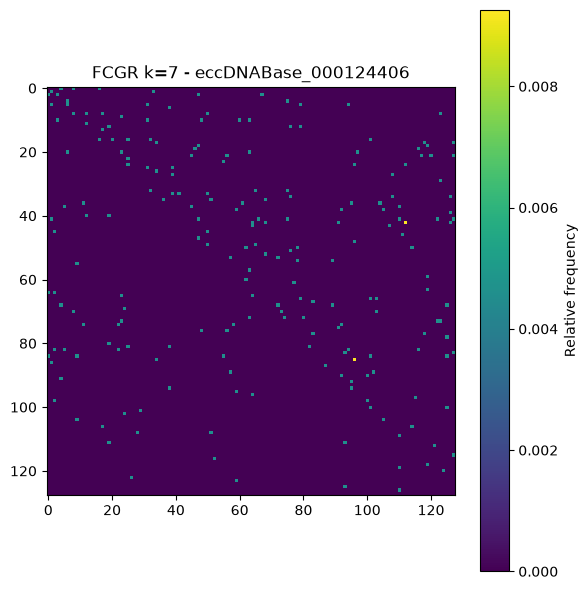

In [24]:
plt.figure(
    figsize=(6, 6)
)


plt.imshow(
    test_fcgr.squeeze(0),
    interpolation="nearest"
)


plt.title(
    f"FCGR k={DEFAULT_K} - {test_id}"
)


plt.colorbar(
    label="Relative frequency"
)


plt.tight_layout()
plt.show()

# Siamese PairDataset

La Siamese Network non utilizza singoli sample durante il training,
ma coppie di FCGR.

Una coppia positiva contiene due sample appartenenti alla stessa classe:

`(A, P) -> target = 1`

Una coppia negativa contiene sample appartenenti a classi differenti:

`(A, N) -> target = 0`

Le coppie NON vengono salvate preventivamente.

Il `PairDataset` sceglie dinamicamente:

1. la classe dell'anchor;
2. un sample anchor;
3. se generare una coppia positiva o negativa;
4. il secondo sample.

La classe dell'anchor viene campionata uniformemente tra le 18 classi,
riducendo ulteriormente il rischio che le classi maggiori dominino
la generazione delle coppie.

Per le coppie negative anche la seconda classe viene scelta uniformemente
tra tutte le classi differenti da quella dell'anchor.

Le FCGR vengono calcolate on demand e conservate temporaneamente in una
cache LRU, evitando di ricalcolare continuamente le rappresentazioni
dei sample utilizzati più volte.

In [25]:
class SiamesePairDataset(
    Dataset
):

    def __init__(
        self,
        metadata,
        sequences,
        k=6,
        pairs_per_epoch=50_000,
        positive_probability=0.5,
        seed=42,
        deterministic=False,
        cache_size=4096
    ):

        self.metadata = (
            metadata[
                [
                    "id",
                    "class_id",
                    "disease_clean"
                ]
            ]
            .copy()
        )


        self.metadata[
            "id"
        ] = (
            self.metadata[
                "id"
            ]
            .astype(str)
        )


        self.sequences = sequences

        self.k = k

        self.pairs_per_epoch = (
            pairs_per_epoch
        )

        self.positive_probability = (
            positive_probability
        )

        self.seed = seed

        self.deterministic = (
            deterministic
        )


        # --------------------------------------------
        # Raggruppamento degli ID per classe
        # --------------------------------------------

        self.class_to_ids = {}


        for (
            class_id,
            group
        ) in self.metadata.groupby(
            "class_id"
        ):

            self.class_to_ids[
                int(class_id)
            ] = (
                group["id"]
                .astype(str)
                .to_numpy()
            )


        self.classes = np.array(
            sorted(
                self.class_to_ids.keys()
            ),
            dtype=np.int64
        )


        # --------------------------------------------
        # Verifica positiva:
        # servono almeno due sample per classe
        # --------------------------------------------

        for (
            class_id,
            ids
        ) in self.class_to_ids.items():

            if len(ids) < 2:

                raise ValueError(
                    f"La classe {class_id} "
                    "ha meno di 2 sample."
                )


        # RNG utilizzato durante training

        self.rng = (
            np.random.default_rng(
                seed
            )
        )


        # --------------------------------------------
        # Cache FCGR
        # --------------------------------------------

        self._cached_fcgr = (
            lru_cache(
                maxsize=cache_size
            )(
                self._compute_fcgr_tensor
            )
        )


    def __len__(
        self
    ):

        return self.pairs_per_epoch


    def _compute_fcgr_tensor(
        self,
        sample_id
    ):

        sequence = (
            self.sequences[
                sample_id
            ]
        )


        tensor, n_valid = (
            sequence_to_fcgr_tensor(
                sequence,
                self.k
            )
        )


        if n_valid == 0:

            raise ValueError(
                f"Nessun k-mer valido "
                f"per sample {sample_id}"
            )


        return tensor


    def _sample_pair_ids(
        self,
        rng
    ):

        # --------------------------------------------
        # Scegliamo uniformemente la classe anchor
        # --------------------------------------------

        class1 = int(
            rng.choice(
                self.classes
            )
        )


        ids_class1 = (
            self.class_to_ids[
                class1
            ]
        )


        id1 = str(
            rng.choice(
                ids_class1
            )
        )


        # --------------------------------------------
        # Positive / Negative
        # --------------------------------------------

        is_positive = (
            rng.random()
            <
            self.positive_probability
        )


        if is_positive:

            class2 = class1


            # Evitiamo di usare esattamente
            # lo stesso sample due volte.

            id2 = id1


            while id2 == id1:

                id2 = str(
                    rng.choice(
                        ids_class1
                    )
                )


            target = 1.0


        else:

            possible_classes = (
                self.classes[
                    self.classes
                    != class1
                ]
            )


            class2 = int(
                rng.choice(
                    possible_classes
                )
            )


            ids_class2 = (
                self.class_to_ids[
                    class2
                ]
            )


            id2 = str(
                rng.choice(
                    ids_class2
                )
            )


            target = 0.0


        return (
            id1,
            id2,
            class1,
            class2,
            target
        )


    def get_pair_info(
        self,
        index
    ):

        """
        Produce solamente le informazioni
        della coppia senza calcolare le FCGR.

        Utile per i sanity check.
        """

        rng = np.random.default_rng(
            self.seed
            + index
        )


        (
            id1,
            id2,
            class1,
            class2,
            target
        ) = self._sample_pair_ids(
            rng
        )


        return {

            "id1": id1,

            "id2": id2,

            "class1": class1,

            "class2": class2,

            "target": target
        }


    def __getitem__(
        self,
        index
    ):

        # --------------------------------------------
        # Validation / Test:
        # la stessa posizione produce sempre
        # la stessa coppia.
        # --------------------------------------------

        if self.deterministic:

            rng = (
                np.random.default_rng(
                    self.seed
                    + index
                )
            )


        # --------------------------------------------
        # Train:
        # coppie dinamiche a ogni accesso.
        # --------------------------------------------

        else:

            rng = self.rng


        (
            id1,
            id2,
            class1,
            class2,
            target
        ) = self._sample_pair_ids(
            rng
        )


        fcgr1 = (
            self._cached_fcgr(
                id1
            )
        )


        fcgr2 = (
            self._cached_fcgr(
                id2
            )
        )


        return {

            "x1": fcgr1,

            "x2": fcgr2,

            "target": torch.tensor(
                target,
                dtype=torch.float32
            ),

            "id1": id1,

            "id2": id2,

            "class1": class1,

            "class2": class2
        }

# Creazione dei PairDataset

Il training dataset utilizza coppie dinamiche.

Validation e test utilizzano invece una generazione deterministica:
a parità di seed e indice viene sempre prodotta la stessa coppia.

Questo permette di confrontare in modo riproducibile le performance
del modello tra epoche ed esperimenti differenti.

In [26]:
train_pair_dataset = SiamesePairDataset(
    metadata=train_metadata,
    sequences=sequence_store,
    k=DEFAULT_K,
    pairs_per_epoch=TRAIN_PAIRS_PER_EPOCH,
    positive_probability=POSITIVE_PAIR_PROBABILITY,
    seed=RANDOM_STATE,
    deterministic=False,
    cache_size=FCGR_CACHE_SIZE
)


val_pair_dataset = SiamesePairDataset(
    metadata=val_pair_pool,
    sequences=sequence_store,
    k=DEFAULT_K,
    pairs_per_epoch=VAL_PAIRS,
    positive_probability=POSITIVE_PAIR_PROBABILITY,
    seed=RANDOM_STATE + 10_000,
    deterministic=True,
    cache_size=FCGR_CACHE_SIZE
)


test_pair_dataset = SiamesePairDataset(
    metadata=test_pair_pool,
    sequences=sequence_store,
    k=DEFAULT_K,
    pairs_per_epoch=TEST_PAIRS,
    positive_probability=POSITIVE_PAIR_PROBABILITY,
    seed=RANDOM_STATE + 20_000,
    deterministic=True,
    cache_size=FCGR_CACHE_SIZE
)


print(
    "Train pairs / epoch:",
    len(train_pair_dataset)
)

print(
    "Validation pairs:",
    len(val_pair_dataset)
)

print(
    "Test pairs:",
    len(test_pair_dataset)
)

Train pairs / epoch: 50000
Validation pairs: 10000
Test pairs: 10000


In [27]:
pair_diagnostics = []


for i in range(5000):

    info = (
        train_pair_dataset
        .get_pair_info(i)
    )


    pair_diagnostics.append(
        info
    )


pair_diagnostics = pd.DataFrame(
    pair_diagnostics
)


pair_diagnostics.head()

,id1,id2,class1,class2,target
0,eccDNABase_000637099,CircleBaseV2_002812828,1,1,1.0
1,eccDNABase_000003672,CircleBaseV2_002993728,9,9,1.0
2,eccDNABase_000573761,eccDNABase_000574175,12,12,1.0
3,eccDNABase_000001132,CircleBaseV2_002992084,16,9,0.0
4,eccDNABase_000006183,eccDNABase_000004010,9,9,1.0


In [28]:
pair_diagnostics[
    "pair_type"
] = np.where(
    pair_diagnostics[
        "target"
    ] == 1,
    "positive",
    "negative"
)


pair_diagnostics[
    "pair_type"
].value_counts(
    normalize=True
)

pair_type
negative    0.5026
positive    0.4974
Name: proportion, dtype: float64

In [29]:
positive_errors = (
    pair_diagnostics[
        pair_diagnostics[
            "target"
        ] == 1
    ][
        "class1"
    ]
    !=
    pair_diagnostics[
        pair_diagnostics[
            "target"
        ] == 1
    ][
        "class2"
    ]
).sum()


negative_errors = (
    pair_diagnostics[
        pair_diagnostics[
            "target"
        ] == 0
    ][
        "class1"
    ]
    ==
    pair_diagnostics[
        pair_diagnostics[
            "target"
        ] == 0
    ][
        "class2"
    ]
).sum()


same_sample_positive = (
    pair_diagnostics[
        pair_diagnostics[
            "target"
        ] == 1
    ][
        "id1"
    ]
    ==
    pair_diagnostics[
        pair_diagnostics[
            "target"
        ] == 1
    ][
        "id2"
    ]
).sum()


print(
    "Positive pair con classi diverse:",
    positive_errors
)

print(
    "Negative pair con stessa classe:",
    negative_errors
)

print(
    "Positive pair con stesso sample:",
    same_sample_positive
)

Positive pair con classi diverse: 0
Negative pair con stessa classe: 0
Positive pair con stesso sample: 0


In [30]:
anchor_distribution = (
    pair_diagnostics[
        "class1"
    ]
    .value_counts()
    .sort_index()
)


anchor_distribution.index = (
    anchor_distribution.index.map(
        ID_TO_CLASS
    )
)


anchor_distribution

class1
gastric cancer                            264
healthy                                   246
ovarian cancer                            258
prostate cancer                           280
colorectal cancer                         279
lymphoma                                  299
hiv infectious disease                    293
cervical adenocarcinoma                   269
leukemia                                  270
primary pulmonary hypertension            249
cataract                                  303
hypopharyngeal squamous cell carcinoma    267
glioblastoma cancer                       301
melanoma                                  301
dilated cardiomyopathy                    268
hypopharynx cancer                        280
chronic kidney disease                    294
branchio-oculo-facial syndrome (bofs)     279
Name: count, dtype: int64

POSITIVE: hypopharyngeal squamous cell carcinoma  <->  hypopharyngeal squamous cell carcinoma


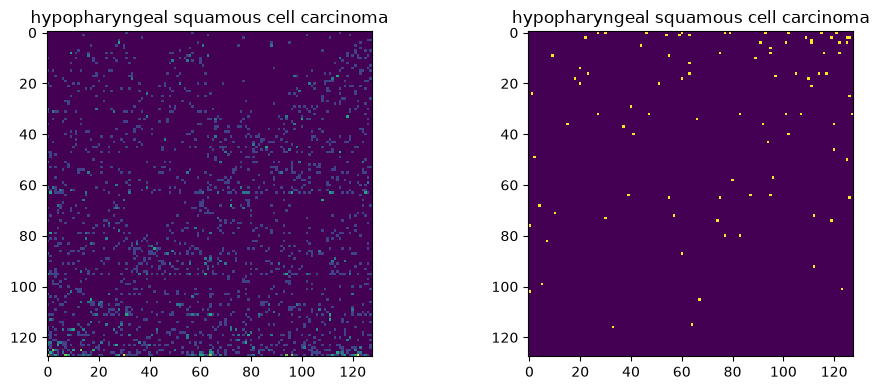

NEGATIVE: leukemia  <->  gastric cancer


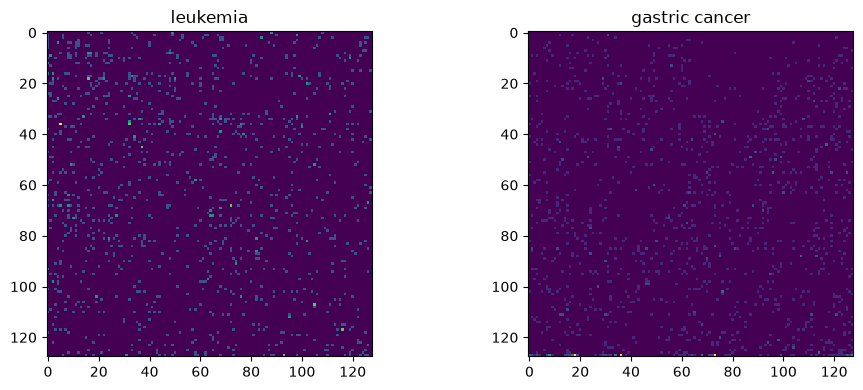

NEGATIVE: ovarian cancer  <->  prostate cancer


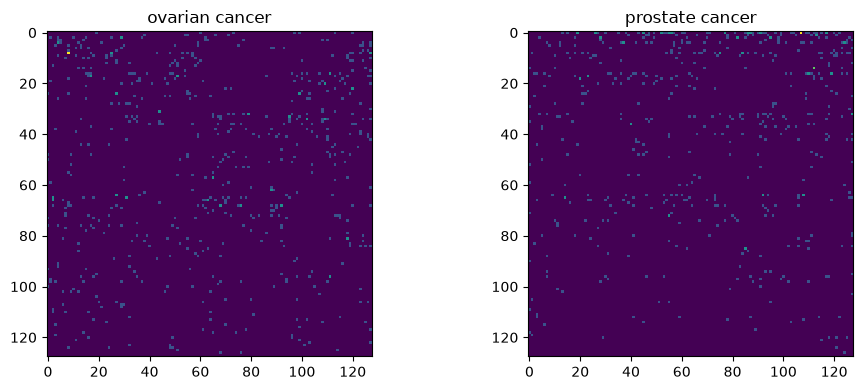

NEGATIVE: lymphoma  <->  ovarian cancer


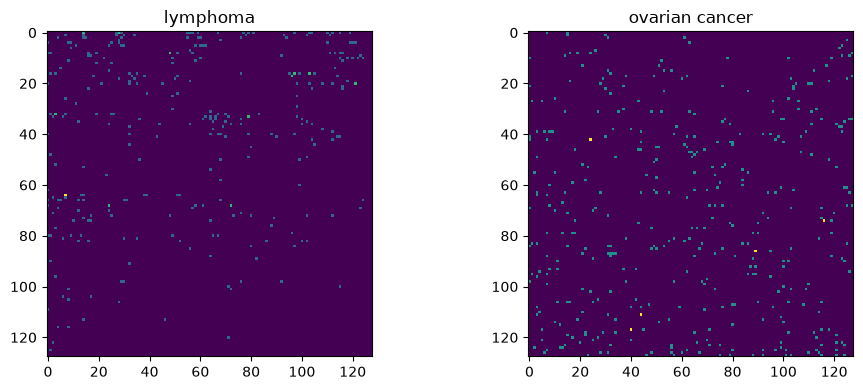

POSITIVE: primary pulmonary hypertension  <->  primary pulmonary hypertension


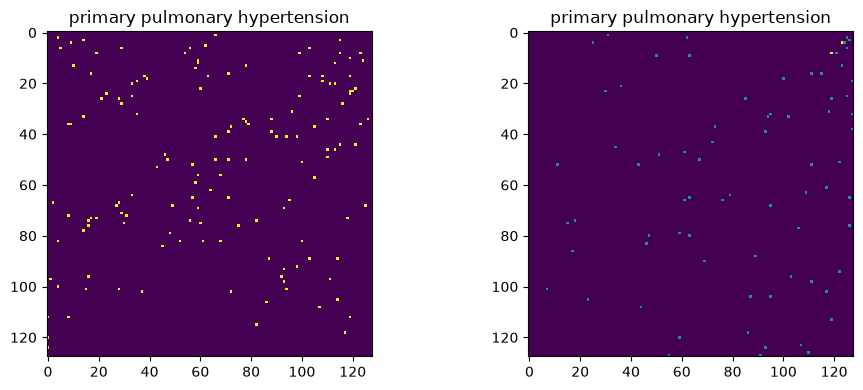

POSITIVE: healthy  <->  healthy


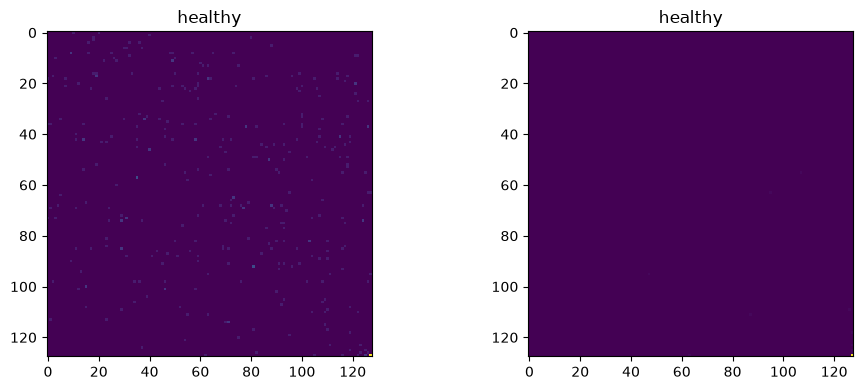

In [31]:
for i in range(6):

    sample = (
        val_pair_dataset[i]
    )


    class1_name = (
        ID_TO_CLASS[
            sample["class1"]
        ]
    )


    class2_name = (
        ID_TO_CLASS[
            sample["class2"]
        ]
    )


    pair_type = (
        "POSITIVE"
        if sample["target"].item() == 1
        else "NEGATIVE"
    )


    print(
        f"{pair_type}: "
        f"{class1_name}  <->  {class2_name}"
    )


    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4)
    )


    axes[0].imshow(
        sample[
            "x1"
        ].squeeze(0),
        interpolation="nearest"
    )

    axes[0].set_title(
        class1_name
    )


    axes[1].imshow(
        sample[
            "x2"
        ].squeeze(0),
        interpolation="nearest"
    )

    axes[1].set_title(
        class2_name
    )


    plt.tight_layout()
    plt.show()

# DataLoader

Una volta verificata la generazione delle coppie, i PairDataset vengono
inseriti nei DataLoader PyTorch.

Poiché le coppie del training vengono già generate casualmente dal Dataset,
non è necessario utilizzare `shuffle=True`.

La forma attesa di un batch con `k=6` è:

- `x1`: `[batch_size, 1, 64, 64]`
- `x2`: `[batch_size, 1, 64, 64]`
- `target`: `[batch_size]`

In [32]:
train_loader = DataLoader(
    train_pair_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


val_loader = DataLoader(
    val_pair_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


test_loader = DataLoader(
    test_pair_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

In [33]:
batch = next(
    iter(
        train_loader
    )
)


print(
    "x1:",
    batch["x1"].shape,
    batch["x1"].dtype
)

print(
    "x2:",
    batch["x2"].shape,
    batch["x2"].dtype
)

print(
    "target:",
    batch["target"].shape,
    batch["target"].dtype
)

print(
    "class1:",
    batch["class1"].shape
)

print(
    "class2:",
    batch["class2"].shape
)

x1: torch.Size([64, 1, 128, 128]) torch.float32
x2: torch.Size([64, 1, 128, 128]) torch.float32
target: torch.Size([64]) torch.float32
class1: torch.Size([64])
class2: torch.Size([64])


In [34]:
import time


# Ripartiamo con una cache vuota
train_pair_dataset._cached_fcgr.cache_clear()


N_BENCHMARK_BATCHES = 5


start = time.perf_counter()

n_pairs = 0


for batch_idx, batch in enumerate(
    train_loader
):

    n_pairs += batch["target"].shape[0]

    if batch_idx + 1 >= N_BENCHMARK_BATCHES:
        break


elapsed = time.perf_counter() - start


print(
    "Batch testati:",
    N_BENCHMARK_BATCHES
)

print(
    "Pair elaborati:",
    n_pairs
)

print(
    f"Tempo totale: {elapsed:.2f} s"
)

print(
    f"Tempo medio/batch: "
    f"{elapsed / N_BENCHMARK_BATCHES:.3f} s"
)

print(
    f"Pair/s: "
    f"{n_pairs / elapsed:.1f}"
)

print(
    "\nFCGR cache:"
)

print(
    train_pair_dataset
    ._cached_fcgr
    .cache_info()
)

Batch testati: 5
Pair elaborati: 320
Tempo totale: 4.98 s
Tempo medio/batch: 0.996 s
Pair/s: 64.2

FCGR cache:
CacheInfo(hits=4, misses=636, maxsize=4096, currsize=636)


In [36]:
print(
    "Positive nel batch:",
    (
        batch["target"] == 1
    ).sum().item()
)

print(
    "Negative nel batch:",
    (
        batch["target"] == 0
    ).sum().item()
)

Positive nel batch: 35
Negative nel batch: 29


In [37]:
val_sample_a = (
    val_pair_dataset[10]
)

val_sample_b = (
    val_pair_dataset[10]
)


print(
    "ID1 uguale:",
    val_sample_a[
        "id1"
    ]
    ==
    val_sample_b[
        "id1"
    ]
)

print(
    "ID2 uguale:",
    val_sample_a[
        "id2"
    ]
    ==
    val_sample_b[
        "id2"
    ]
)

print(
    "Target uguale:",
    val_sample_a[
        "target"
    ].item()
    ==
    val_sample_b[
        "target"
    ].item()
)

ID1 uguale: True
ID2 uguale: True
Target uguale: True


# Precomputazione persistente delle FCGR

Il benchmark della generazione on demand ha mostrato che il calcolo delle
FCGR durante il caricamento dei batch rappresenta un collo di bottiglia.

La cache LRU risulta poco efficace perché il training contiene un numero
elevato di sample e le coppie vengono generate casualmente.

Per evitare di ricalcolare ripetutamente la stessa FCGR, tutte le
rappresentazioni necessarie alla pipeline pair-based vengono quindi
precomputate una sola volta con `k=6`.

Le matrici vengono salvate in un unico file NumPy memory-mapped.

Questo permette di:

- evitare migliaia di file `.npy` separati;
- non caricare contemporaneamente tutte le FCGR in RAM;
- accedere direttamente alla matrice associata a ciascun sample;
- mantenere le FCGR in formato `float32`;
- ridurre il tempo di preparazione dei batch.

La versione on-demand precedente viene mantenuta nel notebook come baseline
prestazionale.

In [38]:
FCGR_CACHE_DIR = (
    PROCESSED_DIR
    / "fcgr_cache"
)

FCGR_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FCGR_MEMMAP_PATH = (
    FCGR_CACHE_DIR
    / f"fcgr_k{DEFAULT_K}.npy"
)

FCGR_INDEX_PATH = (
    FCGR_CACHE_DIR
    / f"fcgr_k{DEFAULT_K}_index.tsv"
)

FCGR_META_PATH = (
    FCGR_CACHE_DIR
    / f"fcgr_k{DEFAULT_K}_metadata.json"
)

FCGR_TEMP_PATH = (
    FCGR_CACHE_DIR
    / f"fcgr_k{DEFAULT_K}_tmp.npy"
)

FCGR_PROGRESS_PATH = (
    FCGR_CACHE_DIR
    / f"fcgr_k{DEFAULT_K}_progress.json"
)


# ============================================================
# SAMPLE REALMENTE NECESSARI
# ============================================================

# Train completo + pool pair-based di validation + test.

required_fcgr_metadata = pd.concat(
    [
        train_metadata,
        val_pair_pool,
        test_pair_pool
    ],
    ignore_index=True
)


required_fcgr_metadata = (
    required_fcgr_metadata
    .drop_duplicates(
        subset="id"
    )
    .copy()
)


required_fcgr_metadata["id"] = (
    required_fcgr_metadata["id"]
    .astype(str)
)


# Ordine deterministico:
# fondamentale perché la riga della matrice
# diventerà l'indice persistente del sample.

required_fcgr_metadata = (
    required_fcgr_metadata
    .sort_values("id")
    .reset_index(drop=True)
)


required_fcgr_metadata.insert(
    0,
    "fcgr_row",
    np.arange(
        len(required_fcgr_metadata),
        dtype=np.int64
    )
)


N_FCGR_SAMPLES = len(
    required_fcgr_metadata
)

FCGR_SIDE = 2 ** DEFAULT_K


expected_bytes = (
    N_FCGR_SAMPLES
    * FCGR_SIDE
    * FCGR_SIDE
    * np.dtype(np.float32).itemsize
)


print(
    "Sample da precomputare:",
    f"{N_FCGR_SAMPLES:,}"
)

print(
    "Shape FCGR:",
    f"{FCGR_SIDE}x{FCGR_SIDE}"
)

print(
    "dtype:",
    np.float32
)

print(
    "Dimensione teorica:",
    f"{expected_bytes / (1024 ** 3):.2f} GiB"
)

print()

print(
    "FCGR file:",
    FCGR_MEMMAP_PATH
)

print(
    "Index file:",
    FCGR_INDEX_PATH
)

Sample da precomputare: 150,272
Shape FCGR: 128x128
dtype: <class 'numpy.float32'>
Dimensione teorica: 9.17 GiB

FCGR file: ..\data\processed\fcgr_cache\fcgr_k7.npy
Index file: ..\data\processed\fcgr_cache\fcgr_k7_index.tsv


In [39]:
from numpy.lib.format import open_memmap


CHECKPOINT_EVERY = 5_000


fcgr_ids = (
    required_fcgr_metadata["id"]
    .tolist()
)


# ============================================================
# CASO 1:
# FCGR già completamente precomputate
# ============================================================

if (
    FCGR_MEMMAP_PATH.exists()
    and FCGR_INDEX_PATH.exists()
):

    print(
        "FCGR già precomputate."
    )

    print(
        "La generazione viene saltata."
    )


# ============================================================
# CASO 2:
# bisogna generarle
# ============================================================

else:

    # --------------------------------------------------------
    # Ripresa da checkpoint
    # --------------------------------------------------------

    if (
        FCGR_TEMP_PATH.exists()
        and FCGR_PROGRESS_PATH.exists()
    ):

        print(
            "Precomputazione precedente trovata."
        )

        print(
            "Ripresa dal checkpoint..."
        )


        with open(
            FCGR_PROGRESS_PATH,
            "r",
            encoding="utf-8"
        ) as f:

            progress_info = json.load(f)


        start_row = int(
            progress_info[
                "next_row"
            ]
        )


        fcgr_memmap_write = np.load(
            FCGR_TEMP_PATH,
            mmap_mode="r+"
        )


        expected_shape = (
            N_FCGR_SAMPLES,
            FCGR_SIDE,
            FCGR_SIDE
        )


        if (
            fcgr_memmap_write.shape
            != expected_shape
        ):

            raise RuntimeError(
                "Il file temporaneo FCGR "
                "ha una shape incompatibile."
            )


        print(
            "Ripresa dalla riga:",
            f"{start_row:,}"
        )


    # --------------------------------------------------------
    # Nuova precomputazione
    # --------------------------------------------------------

    else:

        if FCGR_TEMP_PATH.exists():

            FCGR_TEMP_PATH.unlink()


        print(
            "Creazione nuovo file FCGR..."
        )


        fcgr_memmap_write = open_memmap(
            FCGR_TEMP_PATH,
            mode="w+",
            dtype=np.float32,
            shape=(
                N_FCGR_SAMPLES,
                FCGR_SIDE,
                FCGR_SIDE
            )
        )


        start_row = 0


    # --------------------------------------------------------
    # Generazione
    # --------------------------------------------------------

    for row in range(
        start_row,
        N_FCGR_SAMPLES
    ):

        sample_id = fcgr_ids[
            row
        ]


        sequence = sequence_store[
            sample_id
        ]


        fcgr_counts, n_valid = (
            compute_fcgr(
                sequence,
                DEFAULT_K
            )
        )


        if n_valid == 0:

            raise ValueError(
                "Nessun k-mer valido "
                f"per sample {sample_id}"
            )


        fcgr_normalized = (
            normalize_fcgr(
                fcgr_counts
            )
        )


        fcgr_memmap_write[
            row
        ] = fcgr_normalized


        # ----------------------------------------------------
        # Checkpoint
        # ----------------------------------------------------

        if (
            (row + 1)
            % CHECKPOINT_EVERY
            == 0
            or
            (row + 1)
            == N_FCGR_SAMPLES
        ):

            fcgr_memmap_write.flush()


            progress_info = {
                "next_row": row + 1,
                "total_rows":
                    N_FCGR_SAMPLES,
                "k":
                    DEFAULT_K
            }


            with open(
                FCGR_PROGRESS_PATH,
                "w",
                encoding="utf-8"
            ) as f:

                json.dump(
                    progress_info,
                    f,
                    indent=4
                )


            print(
                "FCGR generate:",
                f"{row + 1:,}",
                "/",
                f"{N_FCGR_SAMPLES:,}"
            )


    # --------------------------------------------------------
    # Chiusura del memmap
    # --------------------------------------------------------

    fcgr_memmap_write.flush()

    del fcgr_memmap_write


    # --------------------------------------------------------
    # Il file temporaneo diventa definitivo
    # solo dopo il completamento
    # --------------------------------------------------------

    FCGR_TEMP_PATH.replace(
        FCGR_MEMMAP_PATH
    )


    # --------------------------------------------------------
    # Salvataggio mapping riga ↔ sample
    # --------------------------------------------------------

    required_fcgr_metadata[
        [
            "fcgr_row",
            "id",
            "class_id",
            "disease_clean",
            "split_cluster"
        ]
    ].to_csv(
        FCGR_INDEX_PATH,
        sep="\t",
        index=False
    )


    # --------------------------------------------------------
    # Metadati cache
    # --------------------------------------------------------

    fcgr_metadata_info = {

        "k":
            DEFAULT_K,

        "n_samples":
            N_FCGR_SAMPLES,

        "shape": [
            N_FCGR_SAMPLES,
            FCGR_SIDE,
            FCGR_SIDE
        ],

        "dtype":
            "float32"
    }


    with open(
        FCGR_META_PATH,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            fcgr_metadata_info,
            f,
            indent=4
        )


    if FCGR_PROGRESS_PATH.exists():

        FCGR_PROGRESS_PATH.unlink()


    print()
    print(
        "Precomputazione completata."
    )

    print(
        "FCGR:",
        FCGR_MEMMAP_PATH
    )

    print(
        "Indice:",
        FCGR_INDEX_PATH
    )

Creazione nuovo file FCGR...
FCGR generate: 5,000 / 150,272
FCGR generate: 10,000 / 150,272
FCGR generate: 15,000 / 150,272
FCGR generate: 20,000 / 150,272
FCGR generate: 25,000 / 150,272
FCGR generate: 30,000 / 150,272
FCGR generate: 35,000 / 150,272
FCGR generate: 40,000 / 150,272
FCGR generate: 45,000 / 150,272
FCGR generate: 50,000 / 150,272
FCGR generate: 55,000 / 150,272
FCGR generate: 60,000 / 150,272
FCGR generate: 65,000 / 150,272
FCGR generate: 70,000 / 150,272
FCGR generate: 75,000 / 150,272
FCGR generate: 80,000 / 150,272
FCGR generate: 85,000 / 150,272
FCGR generate: 90,000 / 150,272
FCGR generate: 95,000 / 150,272
FCGR generate: 100,000 / 150,272
FCGR generate: 105,000 / 150,272
FCGR generate: 110,000 / 150,272
FCGR generate: 115,000 / 150,272
FCGR generate: 120,000 / 150,272
FCGR generate: 125,000 / 150,272
FCGR generate: 130,000 / 150,272
FCGR generate: 135,000 / 150,272
FCGR generate: 140,000 / 150,272
FCGR generate: 145,000 / 150,272
FCGR generate: 150,000 / 150,272
F

In [40]:
fcgr_memmap = np.load(
    FCGR_MEMMAP_PATH,
    mmap_mode="r"
)


fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


print(
    "Memmap shape:",
    fcgr_memmap.shape
)

print(
    "Memmap dtype:",
    fcgr_memmap.dtype
)

print(
    "Righe indice:",
    len(fcgr_index)
)


assert (
    fcgr_memmap.shape
    ==
    (
        len(fcgr_index),
        FCGR_SIDE,
        FCGR_SIDE
    )
)


assert (
    fcgr_memmap.dtype
    == np.float32
)


assert (
    fcgr_index[
        "id"
    ].duplicated().sum()
    == 0
)


id_to_fcgr_row = dict(
    zip(
        fcgr_index["id"],
        fcgr_index["fcgr_row"]
    )
)


missing_in_fcgr_cache = (
    set(
        required_fcgr_metadata[
            "id"
        ]
    )
    -
    set(
        id_to_fcgr_row.keys()
    )
)


print(
    "ID mancanti nella cache:",
    len(
        missing_in_fcgr_cache
    )
)


assert (
    len(
        missing_in_fcgr_cache
    )
    == 0
)

Memmap shape: (150272, 128, 128)
Memmap dtype: float32
Righe indice: 150272
ID mancanti nella cache: 0


In [41]:
test_cached_id = (
    fcgr_index.iloc[0]["id"]
)


test_cached_row = (
    id_to_fcgr_row[
        test_cached_id
    ]
)


test_cached_fcgr = np.asarray(
    fcgr_memmap[
        test_cached_row
    ]
)


print(
    "ID:",
    test_cached_id
)

print(
    "Row:",
    test_cached_row
)

print(
    "Shape:",
    test_cached_fcgr.shape
)

print(
    "dtype:",
    test_cached_fcgr.dtype
)

print(
    "Sum:",
    test_cached_fcgr.sum()
)

print(
    "Min:",
    test_cached_fcgr.min()
)

print(
    "Max:",
    test_cached_fcgr.max()
)

ID: CircleBaseV2_000000009
Row: 0
Shape: (128, 128)
dtype: float32
Sum: 1.0
Min: 0.0
Max: 0.09770115


In [42]:
class SiamesePairDatasetMemmap(
    SiamesePairDataset
):

    """
    Versione ottimizzata del SiamesePairDataset.

    La logica di pair sampling rimane identica,
    ma le FCGR vengono lette da un file NumPy
    memory-mapped invece di essere ricalcolate
    dalla sequenza.
    """

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        k=6,
        pairs_per_epoch=50_000,
        positive_probability=0.5,
        seed=42,
        deterministic=False
    ):

        self.fcgr_memmap = (
            fcgr_memmap
        )

        self.id_to_row = (
            id_to_row
        )


        super().__init__(
            metadata=metadata,

            # Non servono più le sequenze
            sequences={},

            k=k,

            pairs_per_epoch=
                pairs_per_epoch,

            positive_probability=
                positive_probability,

            seed=seed,

            deterministic=
                deterministic,

            # Disabilitiamo la vecchia
            # cache LRU:
            # il backing store ora è il memmap.
            cache_size=0
        )


    def _compute_fcgr_tensor(
        self,
        sample_id
    ):

        sample_id = str(
            sample_id
        )


        row = self.id_to_row[
            sample_id
        ]


        # Copia piccola (64x64) dalla memoria
        # mappata a un array RAM scrivibile.
        #
        # Evita warning PyTorch relativi
        # agli array NumPy read-only.

        fcgr = np.array(
            self.fcgr_memmap[
                row
            ],
            dtype=np.float32,
            copy=True
        )


        tensor = (
            torch.from_numpy(
                fcgr
            )
            .unsqueeze(0)
        )


        return tensor

In [43]:
train_pair_dataset_mm = (
    SiamesePairDatasetMemmap(

        metadata=train_metadata,

        fcgr_memmap=
            fcgr_memmap,

        id_to_row=
            id_to_fcgr_row,

        k=DEFAULT_K,

        pairs_per_epoch=
            TRAIN_PAIRS_PER_EPOCH,

        positive_probability=
            POSITIVE_PAIR_PROBABILITY,

        seed=
            RANDOM_STATE,

        deterministic=False
    )
)


val_pair_dataset_mm = (
    SiamesePairDatasetMemmap(

        metadata=val_pair_pool,

        fcgr_memmap=
            fcgr_memmap,

        id_to_row=
            id_to_fcgr_row,

        k=DEFAULT_K,

        pairs_per_epoch=
            VAL_PAIRS,

        positive_probability=
            POSITIVE_PAIR_PROBABILITY,

        seed=
            RANDOM_STATE
            + 10_000,

        deterministic=True
    )
)


test_pair_dataset_mm = (
    SiamesePairDatasetMemmap(

        metadata=test_pair_pool,

        fcgr_memmap=
            fcgr_memmap,

        id_to_row=
            id_to_fcgr_row,

        k=DEFAULT_K,

        pairs_per_epoch=
            TEST_PAIRS,

        positive_probability=
            POSITIVE_PAIR_PROBABILITY,

        seed=
            RANDOM_STATE
            + 20_000,

        deterministic=True
    )
)


print(
    "Train pairs:",
    len(
        train_pair_dataset_mm
    )
)

print(
    "Validation pairs:",
    len(
        val_pair_dataset_mm
    )
)

print(
    "Test pairs:",
    len(
        test_pair_dataset_mm
    )
)

Train pairs: 50000
Validation pairs: 10000
Test pairs: 10000


In [44]:
train_loader_mm = DataLoader(

    train_pair_dataset_mm,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


val_loader_mm = DataLoader(

    val_pair_dataset_mm,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


test_loader_mm = DataLoader(

    test_pair_dataset_mm,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)

In [45]:
batch_mm = next(
    iter(
        train_loader_mm
    )
)


print(
    "x1:",
    batch_mm["x1"].shape,
    batch_mm["x1"].dtype
)

print(
    "x2:",
    batch_mm["x2"].shape,
    batch_mm["x2"].dtype
)

print(
    "target:",
    batch_mm["target"].shape,
    batch_mm["target"].dtype
)


print()

print(
    "Positive:",
    (
        batch_mm[
            "target"
        ] == 1
    ).sum().item()
)

print(
    "Negative:",
    (
        batch_mm[
            "target"
        ] == 0
    ).sum().item()
)

x1: torch.Size([64, 1, 128, 128]) torch.float32
x2: torch.Size([64, 1, 128, 128]) torch.float32
target: torch.Size([64]) torch.float32

Positive: 35
Negative: 29


In [46]:
PAIR_CHECK_INDEX = 10


old_pair = (
    val_pair_dataset[
        PAIR_CHECK_INDEX
    ]
)


new_pair = (
    val_pair_dataset_mm[
        PAIR_CHECK_INDEX
    ]
)


print(
    "ID1 uguale:",
    old_pair["id1"]
    ==
    new_pair["id1"]
)

print(
    "ID2 uguale:",
    old_pair["id2"]
    ==
    new_pair["id2"]
)

print(
    "Class1 uguale:",
    old_pair["class1"]
    ==
    new_pair["class1"]
)

print(
    "Class2 uguale:",
    old_pair["class2"]
    ==
    new_pair["class2"]
)

print(
    "Target uguale:",
    old_pair["target"].item()
    ==
    new_pair["target"].item()
)


print(
    "FCGR1 uguale:",
    torch.allclose(
        old_pair["x1"],
        new_pair["x1"],
        atol=1e-7
    )
)

print(
    "FCGR2 uguale:",
    torch.allclose(
        old_pair["x2"],
        new_pair["x2"],
        atol=1e-7
    )
)

ID1 uguale: True
ID2 uguale: True
Class1 uguale: True
Class2 uguale: True
Target uguale: True
FCGR1 uguale: True
FCGR2 uguale: True


In [47]:
N_BENCHMARK_BATCHES_MM = 20


start_mm = time.perf_counter()

n_pairs_mm = 0


for (
    batch_idx,
    benchmark_batch_mm
) in enumerate(
    train_loader_mm
):

    n_pairs_mm += (
        benchmark_batch_mm[
            "target"
        ].shape[0]
    )


    if (
        batch_idx + 1
        >= N_BENCHMARK_BATCHES_MM
    ):
        break


elapsed_mm = (
    time.perf_counter()
    - start_mm
)


avg_batch_mm = (
    elapsed_mm
    / N_BENCHMARK_BATCHES_MM
)


print(
    "Batch testati:",
    N_BENCHMARK_BATCHES_MM
)

print(
    "Pair elaborati:",
    n_pairs_mm
)

print(
    f"Tempo totale: "
    f"{elapsed_mm:.3f} s"
)

print(
    f"Tempo medio/batch: "
    f"{avg_batch_mm:.4f} s"
)

print(
    f"Pair/s: "
    f"{n_pairs_mm / elapsed_mm:.1f}"
)

Batch testati: 20
Pair elaborati: 1280
Tempo totale: 0.439 s
Tempo medio/batch: 0.0219 s
Pair/s: 2918.3


In [48]:
old_avg_batch = (
    elapsed
    / N_BENCHMARK_BATCHES
)


new_avg_batch = (
    elapsed_mm
    / N_BENCHMARK_BATCHES_MM
)


speedup = (
    old_avg_batch
    / new_avg_batch
)


benchmark_comparison = pd.DataFrame(
    {
        "storage": [
            "FCGR on demand",
            "FCGR memmap"
        ],

        "seconds_per_batch": [
            old_avg_batch,
            new_avg_batch
        ],

        "pairs_per_second": [
            (
                BATCH_SIZE
                / old_avg_batch
            ),

            (
                BATCH_SIZE
                / new_avg_batch
            )
        ]
    }
)


display(
    benchmark_comparison
)


print(
    f"Speed-up: "
    f"{speedup:.2f}x"
)

,storage,seconds_per_batch,pairs_per_second
0,FCGR on demand,0.996318,64.236518
1,FCGR memmap,0.021930,2918.347376


Speed-up: 45.43x


In [49]:
PAIR_CONFIG = {

    "k":
        DEFAULT_K,

    "fcgr_storage":
        "numpy_memmap",

    "fcgr_path":
        str(
            FCGR_MEMMAP_PATH
        ),

    "fcgr_index_path":
        str(
            FCGR_INDEX_PATH
        ),

    "fcgr_dtype":
        "float32",

    "fcgr_shape": [
        FCGR_SIDE,
        FCGR_SIDE
    ],

    "positive_probability":
        POSITIVE_PAIR_PROBABILITY,

    "train_pairs_per_epoch":
        TRAIN_PAIRS_PER_EPOCH,

    "val_pairs":
        VAL_PAIRS,

    "test_pairs":
        TEST_PAIRS,

    "max_eval_samples_per_class":
        MAX_EVAL_SAMPLES_PER_CLASS,

    "batch_size":
        BATCH_SIZE,

    "random_state":
        RANDOM_STATE,

    "n_classes":
        int(
            metadata[
                "class_id"
            ].nunique()
        ),

    "pair_dataset":
        "SiamesePairDatasetMemmap"
}


PAIR_CONFIG_PATH = (
    PROCESSED_DIR
    / "siamese_pair_config.json"
)


with open(
    PAIR_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        PAIR_CONFIG,
        f,
        indent=4
    )


print(
    "Configurazione salvata:",
    PAIR_CONFIG_PATH
)

Configurazione salvata: ..\data\processed\siamese_pair_config.json


In [50]:
VAL_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_val_pair_pool.tsv"
)


TEST_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_test_pair_pool.tsv"
)


val_pair_pool.to_csv(
    VAL_POOL_PATH,
    sep="\t",
    index=False
)


test_pair_pool.to_csv(
    TEST_POOL_PATH,
    sep="\t",
    index=False
)


print(
    "Validation pool:",
    VAL_POOL_PATH
)

print(
    "Test pool:",
    TEST_POOL_PATH
)

Validation pool: ..\data\processed\siamese_val_pair_pool.tsv
Test pool: ..\data\processed\siamese_test_pair_pool.tsv


# Conclusioni della fase 3 — Siamese PairDataset

In questa fase è stata costruita la pipeline dati necessaria per
l'addestramento della Siamese Network.

Il dataset parte dal manifest prodotto nel notebook 01 e utilizza come
rappresentazione iniziale le FCGR con `k=6`, selezionato nel notebook 02.

## Separazione degli split

Train, validation e test vengono mantenuti completamente separati prima
della generazione delle coppie.

In questo modo uno stesso sample non può comparire contemporaneamente
nel training e nella valutazione attraverso coppie differenti.

Il training utilizza tutti i sample precedentemente sottoposti a downsampling.

Per la valutazione pair-based viene utilizzato un pool controllato di
sample provenienti esclusivamente dai rispettivi split di validation e test.

## Generazione dinamica delle coppie

Le coppie non vengono materializzate preventivamente.

Il `SiamesePairDataset` genera dinamicamente:

- positive pairs (`target = 1`) tra sample della stessa classe;
- negative pairs (`target = 0`) tra sample appartenenti a classi differenti.

La probabilità iniziale di generare una positive pair è pari a 0.5.

La classe dell'anchor viene campionata uniformemente, evitando che le classi
con maggiore numerosità dominino il training.

Per le coppie negative anche la seconda classe viene scelta uniformemente
tra tutte le classi differenti dall'anchor.

## FCGR e ottimizzazione del caricamento

Ogni sequenza viene rappresentata mediante una FCGR normalizzata con `k=6`,
corrispondente a una matrice `64 × 64` in formato `float32`.

In una prima implementazione le FCGR venivano calcolate on demand durante
la generazione delle coppie e mantenute temporaneamente tramite una cache LRU.

Un benchmark del DataLoader ha però mostrato un tempo medio di circa
0.879 secondi per batch e una bassa hit rate della cache, dovuta all'elevato
numero di sample e al campionamento casuale delle coppie.

Per eliminare questo collo di bottiglia sono state quindi precompute una sola
volta le 150.272 FCGR necessarie alla pipeline pair-based.

Le matrici sono state memorizzate in un unico file NumPy memory-mapped
in formato `float32`, per una dimensione complessiva di circa 2.29 GiB.

Il PairDataset accede alle FCGR attraverso un mapping `sample_id → row`
senza caricare l'intero dataset in RAM.

È stata verificata l'equivalenza tra la pipeline originale e quella
memory-mapped: ID, classi, target e matrici FCGR risultano identici.

Il nuovo benchmark ha mostrato un tempo medio di circa 0.0062 secondi
per batch, corrispondente a uno speed-up di circa 141× rispetto alla
generazione on demand.

## Riproducibilità

Le coppie del training vengono generate dinamicamente.

Validation e test utilizzano invece un campionamento deterministico:
lo stesso indice produce sempre la stessa coppia.

Questo permette di confrontare in modo riproducibile epoche,
architetture e funzioni di loss differenti.

## DataLoader

I DataLoader producono batch nella forma:

- `x1`: `[batch, 1, 64, 64]`
- `x2`: `[batch, 1, 64, 64]`
- `target`: `[batch]`

La pipeline dati è quindi pronta per essere utilizzata dalla Siamese Network.

## Fase successiva

Nel notebook successivo verrà implementata la CNN encoder condivisa.

Per ogni coppia verranno calcolati due embedding:

`FCGR_1 -> CNN -> z_1`

`FCGR_2 -> CNN -> z_2`

utilizzando la stessa CNN e quindi gli stessi pesi.

Il primo esperimento utilizzerà la distanza euclidea e una Contrastive Loss.

Successivamente verranno confrontate altre configurazioni, tra cui
cosine similarity e Triplet Loss.